In [1]:
import os
import gc
import copy
import torch
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

import timm 
from torch import nn
from torch.optim import Adam
from torchvision import models
import torch.nn.functional as F
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, ConcatDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchinfo import summary

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
# Check accelerator

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [3]:
# Set SEED for reproducibility

SEED = 24520152

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# Train directory path

TRAIN_DIR = '/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [5]:
# Save directory path

SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [6]:
# 3 labels: Glioma Tumor, Meningioma Tumor, Pituitary Tumor

CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [7]:
# Model name

MODEL_NAME = 'MobileNet'
MODEL_NAME

'MobileNet'

In [8]:
# Hyperparameters

BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 3
DROPOUT_RATE = 0.3

In [9]:
def get_data_for_fold(k: int, train_dir: str = TRAIN_DIR, batch_size: int = BATCH_SIZE) -> tuple[DataLoader, DataLoader]:
    """
    Creates PyTorch DataLoaders for K-Fold Cross-Validation, specifically tailored
    for MobileNet transfer learning with ImageNet standards.

    This function sets up a data pipeline that:
    1. Applies standard ImageNet normalization statistics.
    2. Implements strong data augmentation for the training set (using torchvision v2).
    3. Prepares validation data with deterministic preprocessing (Resize -> CenterCrop).
    4. Handles subset selection based on the current fold index 'k'.

    Args:
        k (int): The index of the validation fold (e.g., 1 to 5). 
                 The folder 'Subset_{k}' will be used for validation, while 
                 all other subsets are concatenated for training.
        train_dir (str): Path to the root directory containing the fold subsets 
                         (e.g., 'Subset_1', 'Subset_2', etc.).
        batch_size (int, optional): Number of samples per batch. Defaults to 32.

    Returns:
        tuple: A tuple containing:
            - train_loader (DataLoader): The training data loader (shuffled).
            - val_loader (DataLoader): The validation data loader (not shuffled).
    """

    # Standard ImageNet normalization statistics (Required for MobileNet weights)
    norm_mean=[0.485, 0.456, 0.406]
    norm_std=[0.229, 0.224, 0.225]

    # Training Transform Pipeline
    train_transform = v2.Compose([
        # Resize to 256x256 first. This provides a buffer for subsequent 
        # rotation/translation and cropping, preventing black border artifacts.
        v2.Resize(size=256),

        # Apply Data Augmentation
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(degrees=36),
        v2.RandomAffine(degrees=0, scale=(0.9, 1.1)),
        v2.ColorJitter(brightness=0.1, contrast=0.1),

        # Use CenterCrop to focus on the primary subject
        v2.CenterCrop(size=224),

        # Convert PIL/Numpy to Tensor, cast to Float32, and rescale to [0, 1]
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),

        # Normalize using ImageNet mean and std
        v2.Normalize(mean=norm_mean, std=norm_std),
    ])

    # Validation Transform Pipeline
    val_transform = v2.Compose([
        v2.Resize(size=256),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std)
    ])

    # Data Path Setup
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    train_dirs = [os.path.join(train_dir, f'Subset_{i}') for i in range(1, 6) if i != k]

    # Worker Configuration
    # Determine the optimal number of CPU workers to prevent bottlenecks.
    # Capped at 4 to avoid excessive memory overhead.
    num_workers = min(4, os.cpu_count())

    # Validation Loader
    val_dataset = ImageFolder(root=val_dir, transform=val_transform)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    # Training Loader
    list_train_dataset = [ImageFolder(root=td, transform=train_transform) for td in train_dirs]
    train_dataset = ConcatDataset(datasets=list_train_dataset)
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader

In [10]:
class MobileNet(nn.Module):
    """
    MobileNetV1-based model for image classification using Transfer Learning.
    
    Architecture:
    - Backbone: MobileNetV1 (frozen, ImageNet weights, via timm)
    - Head: Global Average Pooling -> Dropout -> Linear (Dense)
    
    Attributes:
        num_classes (int): Number of target classes.
        dropout_rate (float): Dropout probability.
    """

    def __init__(self, num_classes: int = 3, dropout_rate: float = 0.3) -> None:
        super().__init__()
        
        # Load Backbone: MobileNet V1 with ImageNet weights.
        # 'mobilenetv1_100' in timm corresponds to MobileNet(alpha=1.0) in Keras.
        self.backbone = timm.create_model('mobilenetv1_100', pretrained=True, num_classes=0, global_pool='')
        
        # Freeze Backbone
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Define Custom Classifier Head
 
        
        # Components matching your MobileNetV1 structure
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1) # # Reduces (Batch, 1024, H, W) -> (Batch, 1024, 1, 1)
        self.flatten = nn.Flatten(start_dim=1) # Flatten (Batch, 1024, 1, 1) -> (Batch, 1024)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features=1024, out_features=num_classes) # MobileNet features output exactly 1024 channels

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input image batch (B, C, H, W)

        Returns:
            torch.Tensor: Raw logits (B, num_classes). 
                          NOTE: Does NOT apply Softmax.
        """
        # Feature Extraction (Frozen)
        x = self.backbone(x) 
        
        # Classification Head (Trainable)
        x = self.global_avg_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)
        
        # Output Logits
        logits = self.classifier(x)
        
        return logits

In [11]:
def build_mobilenet(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> MobileNet:
    """
    Factory function to instantiate the customized MobileNet model for Transfer Learning.

    This function initializes a `MobileNet` which includes:
    1. A frozen mobilenet backbone (pre-trained on ImageNet).
    2. A custom trainable classification head (Pooling -> Dropout -> Linear).

    Args:
        num_classes (int, optional): The number of target classes for the classification task. 
            Determines the output size of the final Linear layer. Defaults to 3.
        dropout_rate (float, optional): The probability of an element to be zeroed 
            in the Dropout layer. Used for regularization to prevent overfitting. 
            Defaults to 0.3.

    Returns:
        MobileNet: An initialized PyTorch model instance (subclass of nn.Module), 
            ready to be moved to a device (CPU/GPU) for training or inference.
    """

    model = MobileNet(num_classes=num_classes, dropout_rate=dropout_rate)
    return model

In [12]:
class SparseCategoricalFocalLoss(nn.Module):
    """
    Implements Sparse Categorical Focal Loss for multi-class classification.

    Focal Loss focuses training on hard examples (where the model has low confidence) 
    and down-weights easy examples (where the model has high confidence). 
    It is defined as:
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, gamma: float = 2, alpha: list[float] | None = None, reduction: str = 'mean') -> None:
        """
        Initializes the Focal Loss module.

        Args:
            gamma (float, optional): Focusing parameter. Defaults to 2.0.
            alpha (list[float], optional): A list of weights for each class 
                to handle class imbalance. If None, no weighting is applied. 
                Defaults to None.
            reduction (str, optional): Specifies the reduction to apply to the output:
                'mean': the sum of the output will be divided by the number of elements in the output.
                'sum': the output will be summed.
                'none': no reduction will be applied. Defaults to 'mean'.
        """

        super().__init__()
        
        self.gamma = gamma
        self.reduction = reduction

        if alpha is not None:
            # register_buffer allows 'alpha' to:
            # 1. Be part of the model's state_dict (saved/loaded with the model).
            # 2. Automatically move to the correct device (CPU/GPU) alongside the model.
            # 3. Not be treated as a trainable parameter (no gradients).
            self.register_buffer('alpha', torch.tensor(data=alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Forward pass to compute the focal loss.

        Args:
            logits (torch.Tensor): Raw output scores from the model (before Softmax).
                Shape: (Batch_Size, Num_Classes) or (N, C).
            targets (torch.Tensor): Ground truth class indices.
                Shape: (Batch_Size,) or (N,). Values must be in range [0, C-1].

        Returns:
            torch.Tensor: The computed loss value.
        """

        # 1. Compute Log Softmax: log(p)
        # We use log_softmax because it is numerically more stable than log(softmax(x))
        log_p = F.log_softmax(input=logits, dim=1)                              # Shape: (N, C)  

        # 2. Select the log probability of the true class: log(p_t)
        # gather extracts the values at the specific indices provided by 'targets'
        log_p_t = log_p.gather(dim=1, index=targets.unsqueeze(1)).squeeze(1)    # Shape: (N,)

        # 3. Compute the probability of the true class: p_t = exp(log(p_t))
        p_t = log_p_t.exp()                                                     # Shape: (N,)

        # 4. Compute the Focal Term: (1 - p_t)^gamma
        # If p_t is high (easy example), this term approaches 0.
        # If p_t is low (hard example), this term is large.
        focal_weight = (1 - p_t) ** self.gamma                                  # Shape: (N,)

        # 5. Compute the basic Focal Loss without alpha
        loss = - focal_weight * log_p_t                                         # Shape: (N,)

        # 6. Apply Alpha (Class Balancing) if provided
        if self.alpha is not None:
            # Extract weight corresponding to each target class
            alpha_t = self.alpha.gather(dim=0, index=targets)                   # Shape: (N,)
            loss = alpha_t * loss

        # 7. Apply Reduction (Mean or Sum)
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        
        # If reduction is 'none', return the vector of losses
        return loss

In [13]:
def train_classifier(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-4, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Trains the MobileNet classifier using a custom training loop with Early Stopping 
    and Learning Rate Reduction.

    This function handles the training and validation phases, logs metrics, 
    and saves the best model weights based on validation accuracy.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        fold_k (int): The current K-Fold index (used for naming the saved file).
        save_dir (str, optional): Directory to save the model checkpoints. 
            Defaults to global SAVE_DIR.
        batch_size (int, optional): Batch size for training. 
            Defaults to global BATCH_SIZE.
        epochs (int, optional): Maximum number of training epochs. 
            Defaults to global EPOCHS.
        learning_rate (float, optional): Initial learning rate for the Adam optimizer. 
            Defaults to 1e-4.
        model_name (str, optional): Name prefix for the saved model file. 
            Defaults to global MODEL_NAME.

    Returns:
        dict[str, list[float]]: A dictionary containing the training history:
            - 'loss': List of training losses per epoch.
            - 'accuracy': List of training accuracies per epoch.
            - 'val_loss': List of validation losses per epoch.
            - 'val_accuracy': List of validation accuracies per epoch.
    """

    # 1. Initialize Model & Move to Device
    model = build_mobilenet().to(device=device)

    # Summary
    print(f"\nFold: {fold_k} - Block 5")
    
    print(summary(model, 
            input_size=(BATCH_SIZE, 3, 224, 224),
            col_names=["input_size", "output_size", "num_params", "trainable"],
            col_width=20,
            row_settings=["var_names"],
            depth=1
            ))
    # 2. Setup Optimizer, Loss Function, and Scheduler
    optimizer = Adam(params=model.parameters(), lr=learning_rate)

    # Custom Focal Loss to handle potential class imbalance
    criterion = SparseCategoricalFocalLoss()

    # Reduce learning rate if validation loss stops improving
    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    # 3. Initialize Tracking Variables
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict()) # Deep copy ensures we store the actual weights, not just a reference to the model

    # Early Stopping Configuration
    early_stop_patience = 6
    early_stop_counter = 0

    # Define the path where the best model weights will be saved
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_5_fold_{fold_k}.pth')

    # START TRAINING LOOP
    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()

        # disbale BatchNorm layer of MobileNet
        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        # Create a progress bar for the current epoch
        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False)
        
        for inputs, labels in pbar:
            # Move data to the same device as the model
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # 1. Clear previous gradients
            optimizer.zero_grad()

            # 2. Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # 3. Backward pass (Compute gradients)
            loss.backward()

            # 4. Update weights
            optimizer.step()

            # 5. Accumulate Metrics
            # Multiply by batch size to get the total loss for the batch (denormalize mean)
            train_loss += loss.item() * inputs.size(0)

            # Calculate accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            # Update progress bar description
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Calculate average metrics for the entire epoch
        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        # VALIDATION PHASE
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        # Disable gradient calculation to save memory and computation
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # Accumulate validation metrics
                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        # LOGGING & HISTORY
        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        # CALLBACKS
        # 1. Update Learning Rate Scheduler (monitors validation loss)
        scheduler.step(metrics=epoch_val_loss)

        # 2. Model Checkpoint (Save Best Model)
        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            # 3. Early Stopping Logic
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break
    
    # Restore the best model weights before returning
    model.load_state_dict(state_dict=best_model_weights)

    return history

In [14]:
def test_classifier(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the full training and evaluation pipeline for a specific K-Fold.

    This function performs the following steps:
    1. Trains the model using `train_classifier`.
    2. Loads the best model weights saved during that training session.
    3. Evaluates the loaded model on the validation set.
    4. Generates a performance summary, classification report, and confusion matrix plot.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        fold_k (int): The index of the current fold (used for file naming and titles).
        class_names (list[str], optional): List of class names for reporting and plotting. 
            Defaults to global CLASS_NAMES.
        save_dir (str, optional): Directory to save and load model checkpoints. 
            Defaults to global SAVE_DIR.
        model_name (str, optional): Name prefix for the model. 
            Defaults to global MODEL_NAME.

    Returns:
        float: The final accuracy score on the validation set using the best model weights.
    """

    # 1. Train the model
    # This will run the training loop and save the best weights to disk
    history = train_classifier(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k)

    # 2. Prepare to load the best model
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_5_fold_{fold_k}.pth')

    # Initialize the model architecture and move it to the configured device
    model = build_mobilenet().to(device=device)
    # Load the best weights saved during training
    # map_location: Ensures weights are loaded to the correct device (avoids GPU/CPU mismatch)
    # weights_only=True: Security best practice to prevent loading arbitrary code
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    # 3. Setup Evaluation
    criterion = SparseCategoricalFocalLoss()

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    # Initialize lists to aggregate predictions and true labels for Scikit-Learn metrics
    y_true_list = []
    y_pred_list = []

    # 4. Inference Loop
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Accumulate Batch Loss (multiply by batch size to denormalize)
            val_loss += loss.item() * inputs.size(0)

            # Calculate Batch Accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_val += torch.sum(preds == labels)
            total_val += labels.size(0)

            # Store predictions for reporting
            # .cpu(): Move tensor from GPU to CPU
            # .numpy(): Convert tensor to numpy array
            # .extend(): Flatten the batch and add to the main list
            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    # 5. Calculate Final Average Metrics
    loss = val_loss / total_val
    acc = float(correct_val) / total_val

    # 6. Report Results
    # Create a Summary DataFrame
    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    # Print detailed Classification Report (Precision, Recall, F1-Score)
    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    # 7. Plot Confusion Matrix
    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Fold {fold_k} Block 5)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

In [15]:
def set_trainable_from_block(model: nn.Module, block_num: int) -> None:
    """
    Configures trainability for MobileNetV1 (timm implementation).
    
    Based on inspection, timm groups MobileNetV1 into 5 sequential blocks.
    Indices are 0, 1, 2, 3, 4.
    
    New Mapping:
    - Block 4: Unfreeze Index 4 (Last 7x7 block).
    - Block 3: Unfreeze Index 3, 4 (Last 14x14 blocks).
    - Block 2: Unfreeze Index 2, 3, 4 (Last 28x28 blocks).
    - Block 1: Unfreeze All (0-4).
    Args:
        model (nn.Module): The MobileNet model instance.
        block_num (int): The block number (1 to 4) from which to start training.
            - 4: Unfreeze only the last few blocks.
            - 1: Unfreeze almost the entire backbone.
    """

    # Map the abstract "Block Number" to the actual starting layer index in model.backbone.blocks
    block_indices = {
        4: 4,   
        3: 3,   
        2: 2,  
        1: 0,   
    }

    start_index = block_indices[block_num]

    # 1. Configure Backbone (Feature Extractor)
    # MobileNetV1 in `timm` organizes layers into a 'blocks' Sequential container.
    if hasattr(model.backbone, 'blocks'):
        layers_iterator = model.backbone.blocks.children()
    else:
        layers_iterator = model.backbone.children()
        
    # We iterate through these blocks specifically.
    for i, child in enumerate(layers_iterator):
        if i >= start_index:
            # Unfreeze
            for param in child.parameters():
                param.requires_grad = True
        else:
            # Freeze
            for param in child.parameters():
                param.requires_grad = False

    # 2. Configure Classifier Head
    # The classification head (Linear layers) must always be trainable during fine-tuning
    for param in model.classifier.parameters():
        param.requires_grad = True

In [16]:
def train_block(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, block: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-5, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Fine-tunes a specific block of the MobileNet model (Progressive Fine-Tuning).

    Process:
    1. Identifies the checkpoint from the previous training stage (block + 1).
    2. Loads those weights into the model.
    3. Unfreezes layers starting from the current `block` downwards.
    4. Trains the model with a lower learning rate to adapt features without destroying them.

    Args:
        train_loader (DataLoader): Training data.
        val_loader (DataLoader): Validation data.
        fold_k (int): Fold index.
        block (int): The MobileNet block number to unfreeze (e.g., 5, 4, 3...).
        save_dir (str, optional): Directory for checkpoints. Defaults to SAVE_DIR.
        batch_size (int, optional): Batch size. Defaults to BATCH_SIZE.
        epochs (int, optional): Max epochs. Defaults to EPOCHS.
        learning_rate (float, optional): Learning rate (usually lower for fine-tuning). 
            Defaults to 1e-5.
        model_name (str, optional): Model naming prefix. Defaults to MODEL_NAME.

    Returns:
        dict[str, list[float]]: Training history dictionary.
    """

    # 1. Setup paths for previous and current checkpoints
    prev_block = block + 1
    prev_checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{prev_block}_fold_{fold_k}.pth')

    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.pth')

    # 2. Initialize Model & Load Previous Weights
    model = build_mobilenet().to(device=device)
    model.load_state_dict(state_dict=torch.load(f=prev_checkpoint_path, map_location=device, weights_only=True))
    
    # 3. Unfreeze specific layers
    # Use the helper function to set requires_grad=True for the target block
    set_trainable_from_block(model=model, block_num=block)

    # Summary
    print(f"\nFold: {fold_k} - Block {block}")
    print(summary(model, 
            input_size=(BATCH_SIZE, 3, 224, 224),
            col_names=["input_size", "output_size", "num_params", "trainable"],
            col_width=20,
            row_settings=["var_names"],
            depth=1))
    
    optimizer = Adam(params=model.parameters(), lr=learning_rate)
    
    criterion = SparseCategoricalFocalLoss()

    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict()) # Deep copy ensures we store the actual weights, not just a reference to the model

    early_stop_patience = 6
    early_stop_counter = 0

    for epoch in range(epochs):
        model.train()
        # disbale BatchNorm layer of MobileNet
        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()
        
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False)
        
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        scheduler.step(metrics=epoch_val_loss)

        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break
    
    model.load_state_dict(state_dict=best_model_weights)

    return history

In [17]:
def test_block(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, block: int, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the fine-tuning and evaluation pipeline for a specific MobileNet block.

    Process:
    1. Triggers `train_block` to fine-tune the model from the specified `block`.
    2. Loads the best weights saved during that fine-tuning session.
    3. Evaluates metrics (Loss/Accuracy).
    4. Generates Classification Report and Confusion Matrix.

    Args:
        train_loader (DataLoader): Training data.
        val_loader (DataLoader): Validation data.
        fold_k (int): Current Fold index.
        block (int): The specific block number being fine-tuned (e.g., 5, 4, 3).
        class_names (list[str], optional): Class labels for plotting. Defaults to CLASS_NAMES.
        save_dir (str, optional): Save directory. Defaults to SAVE_DIR.
        model_name (str, optional): Model prefix. Defaults to MODEL_NAME.

    Returns:
        float: Final validation accuracy.
    """

    # 1. Run Fine-Tuning for the specific block
    history = train_block(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k, block=block)

    # 2. Path to the best weights for THIS block
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.pth')

    model = build_mobilenet().to(device=device)
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    criterion = SparseCategoricalFocalLoss()

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(input=outputs, dim=1)
            correct_val += torch.sum(preds == labels)
            total_val += labels.size(0)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    loss = val_loss / total_val
    acc = float(correct_val) / total_val

    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Fold {fold_k} Block {block})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

Fold: 1 block 5


model.safetensors:   0%|          | 0.00/17.0M [00:00<?, ?B/s]


Fold: 1 - Block 5
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     (3,206,976)          False
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,075
Non-trainable params: 3,206,976
Total mult-adds (Units.GIGABYTES): 18.17
Input size (MB): 19.27
F

Epoch 1/50 | loss: 0.5032 - accuracy: 0.4155 | val_loss: 0.4077 - val_accuracy: 0.5074
val_accuracy improved from 0.0000 to 0.5074, saving weights to /kaggle/working/MobileNet_block_5_fold_1.pth


Epoch 2/50 | loss: 0.3877 - accuracy: 0.5789 | val_loss: 0.3362 - val_accuracy: 0.6513
val_accuracy improved from 0.5074 to 0.6513, saving weights to /kaggle/working/MobileNet_block_5_fold_1.pth


...

Epoch 34/50 | loss: 0.1577 - accuracy: 0.8144 | val_loss: 0.1507 - val_accuracy: 0.8100
val_accuracy did not improve from 0.8303


Epoch 35/50 | loss: 0.1523 - accuracy: 0.8279 | val_loss: 0.1506 - val_accuracy: 0.8137
val_accuracy did not improve from 0.8303


Epoch 36/50 | loss: 0.1514 - accuracy: 0.8291 | val_loss: 0.1512 - val_accuracy: 0.8118
val_accuracy did not improve from 0.8303


Epoch 37/50 | loss: 0.1541 - accuracy: 0.8271 | val_loss: 0.1508 - val_accuracy: 0.8118
val_accuracy did not improve from 0.8303


Epoch 38/50 | loss: 0.1583 - accuracy: 0.8263 | val_loss: 0.1525 - val_accuracy: 0.8118
val_accuracy did not improve from 0.8303
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.150927  0.830258
                  precision    recall  f1-score   support

    Glioma Tumor       0.77      0.93      0.84       245
Meningioma Tumor       0.74      0.50      0.60       112
 Pituitary Tumor       0.98      0.90      0.94       185

        accuracy                           0.83       542
       macro avg       0.83      0.78      0.79       542
    weighted avg       0.83      0.83      0.82       542



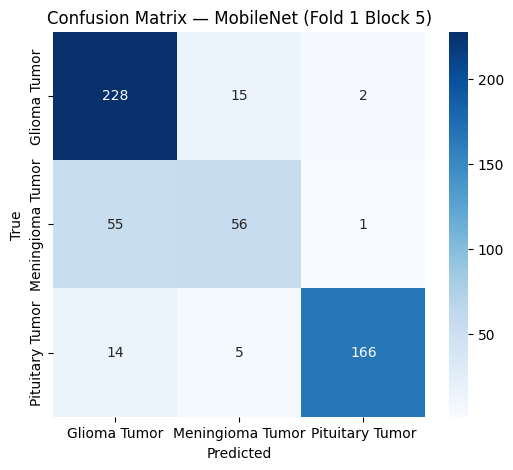

Fold: 1 block 4

Fold: 1 - Block 4
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 1,596,931
Non-trainable params: 1,613,120
Total mult-adds (Units.GIGABYTES): 18.17
In

Epoch 1/50 | loss: 0.1624 - accuracy: 0.8101 | val_loss: 0.1290 - val_accuracy: 0.8303
val_accuracy improved from 0.0000 to 0.8303, saving weights to /kaggle/working/MobileNet_block_4_fold_1.pth


Epoch 2/50 | loss: 0.1539 - accuracy: 0.8172 | val_loss: 0.1283 - val_accuracy: 0.8690
val_accuracy improved from 0.8303 to 0.8690, saving weights to /kaggle/working/MobileNet_block_4_fold_1.pth


Epoch 3/50 | loss: 0.1404 - accuracy: 0.8339 | val_loss: 0.1240 - val_accuracy: 0.8653
val_accuracy did not improve from 0.8690


Epoch 4/50 | loss: 0.1323 - accuracy: 0.8398 | val_loss: 0.1044 - val_accuracy: 0.8764
val_accuracy improved from 0.8690 to 0.8764, saving weights to /kaggle/working/MobileNet_block_4_fold_1.pth


...

Epoch 16/50 | loss: 0.1034 - accuracy: 0.8787 | val_loss: 0.0953 - val_accuracy: 0.8893
val_accuracy did not improve from 0.9114


Epoch 17/50 | loss: 0.1040 - accuracy: 0.8755 | val_loss: 0.0887 - val_accuracy: 0.8856
val_accuracy did not improve from 0.9114


Epoch 18/50 | loss: 0.0996 - accuracy: 0.8803 | val_loss: 0.1138 - val_accuracy: 0.8524
val_accuracy did not improve from 0.9114


Epoch 19/50 | loss: 0.0900 - accuracy: 0.8918 | val_loss: 0.0806 - val_accuracy: 0.9077
val_accuracy did not improve from 0.9114


Epoch 20/50 | loss: 0.0845 - accuracy: 0.8989 | val_loss: 0.0973 - val_accuracy: 0.8838
val_accuracy did not improve from 0.9114
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.083116  0.911439
                  precision    recall  f1-score   support

    Glioma Tumor       0.86      0.97      0.91       245
Meningioma Tumor       0.91      0.70      0.79       112
 Pituitary Tumor       0.99      0.96      0.98       185

        accuracy                           0.91       542
       macro avg       0.92      0.88      0.89       542
    weighted avg       0.92      0.91      0.91       542



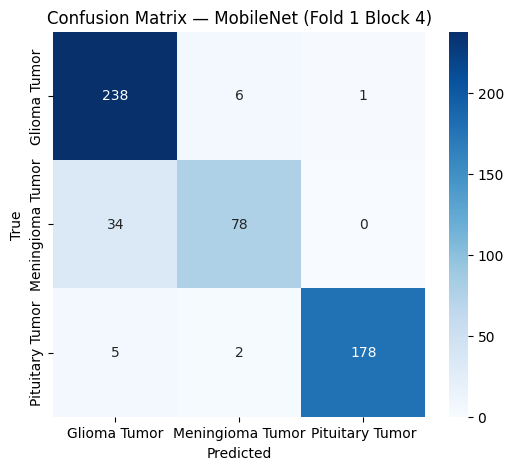

Fold: 1 block 3

Fold: 1 - Block 3
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,075,843
Non-trainable params: 134,208
Total mult-adds (Units.GIGABYTES): 18.17
Inpu

Epoch 1/50 | loss: 0.1588 - accuracy: 0.8125 | val_loss: 0.0900 - val_accuracy: 0.8745
val_accuracy improved from 0.0000 to 0.8745, saving weights to /kaggle/working/MobileNet_block_3_fold_1.pth


Epoch 2/50 | loss: 0.1030 - accuracy: 0.8688 | val_loss: 0.0694 - val_accuracy: 0.9133
val_accuracy improved from 0.8745 to 0.9133, saving weights to /kaggle/working/MobileNet_block_3_fold_1.pth


Epoch 3/50 | loss: 0.0940 - accuracy: 0.8914 | val_loss: 0.0801 - val_accuracy: 0.9004
val_accuracy did not improve from 0.9133


Epoch 4/50 | loss: 0.0977 - accuracy: 0.8870 | val_loss: 0.0528 - val_accuracy: 0.9317
val_accuracy improved from 0.9133 to 0.9317, saving weights to /kaggle/working/MobileNet_block_3_fold_1.pth


...

Epoch 20/50 | loss: 0.0264 - accuracy: 0.9675 | val_loss: 0.0336 - val_accuracy: 0.9557
val_accuracy did not improve from 0.9594


Epoch 21/50 | loss: 0.0225 - accuracy: 0.9718 | val_loss: 0.0326 - val_accuracy: 0.9557
val_accuracy did not improve from 0.9594


Epoch 22/50 | loss: 0.0237 - accuracy: 0.9691 | val_loss: 0.0313 - val_accuracy: 0.9594
val_accuracy did not improve from 0.9594


Epoch 23/50 | loss: 0.0231 - accuracy: 0.9703 | val_loss: 0.0318 - val_accuracy: 0.9594
val_accuracy did not improve from 0.9594


Epoch 24/50 | loss: 0.0242 - accuracy: 0.9687 | val_loss: 0.0335 - val_accuracy: 0.9594
val_accuracy did not improve from 0.9594
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.034635   0.95941
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.98      0.96       245
Meningioma Tumor       0.92      0.88      0.90       112
 Pituitary Tumor       1.00      0.98      0.99       185

        accuracy                           0.96       542
       macro avg       0.96      0.95      0.95       542
    weighted avg       0.96      0.96      0.96       542



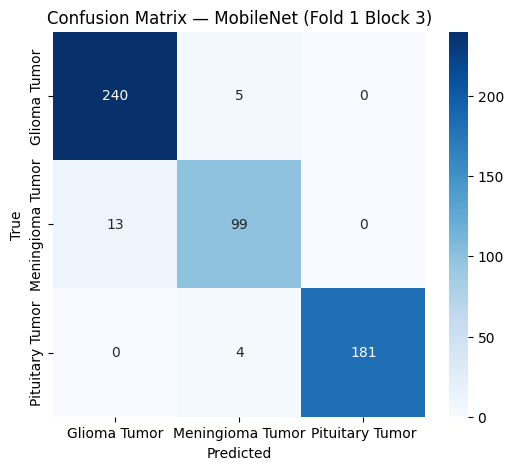

Fold: 1 block 2

Fold: 1 - Block 2
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,179,395
Non-trainable params: 30,656
Total mult-adds (Units.GIGABYTES): 18.17
Input

Epoch 1/50 | loss: 0.0564 - accuracy: 0.9346 | val_loss: 0.0455 - val_accuracy: 0.9428
val_accuracy improved from 0.0000 to 0.9428, saving weights to /kaggle/working/MobileNet_block_2_fold_1.pth


Epoch 2/50 | loss: 0.0400 - accuracy: 0.9481 | val_loss: 0.0627 - val_accuracy: 0.9041
val_accuracy did not improve from 0.9428


Epoch 3/50 | loss: 0.0487 - accuracy: 0.9425 | val_loss: 0.0573 - val_accuracy: 0.9096
val_accuracy did not improve from 0.9428


Epoch 4/50 | loss: 0.0421 - accuracy: 0.9492 | val_loss: 0.0316 - val_accuracy: 0.9723
val_accuracy improved from 0.9428 to 0.9723, saving weights to /kaggle/working/MobileNet_block_2_fold_1.pth


...

Epoch 6/50 | loss: 0.0357 - accuracy: 0.9512 | val_loss: 0.0490 - val_accuracy: 0.9373
val_accuracy did not improve from 0.9723


Epoch 7/50 | loss: 0.0383 - accuracy: 0.9532 | val_loss: 0.0383 - val_accuracy: 0.9557
val_accuracy did not improve from 0.9723


Epoch 8/50 | loss: 0.0329 - accuracy: 0.9611 | val_loss: 0.0352 - val_accuracy: 0.9576
val_accuracy did not improve from 0.9723


Epoch 9/50 | loss: 0.0202 - accuracy: 0.9766 | val_loss: 0.0308 - val_accuracy: 0.9576
val_accuracy did not improve from 0.9723


Epoch 10/50 | loss: 0.0160 - accuracy: 0.9810 | val_loss: 0.0321 - val_accuracy: 0.9557
val_accuracy did not improve from 0.9723
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.031599  0.972325
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.98      0.97       245
Meningioma Tumor       0.96      0.92      0.94       112
 Pituitary Tumor       0.99      0.99      0.99       185

        accuracy                           0.97       542
       macro avg       0.97      0.96      0.97       542
    weighted avg       0.97      0.97      0.97       542



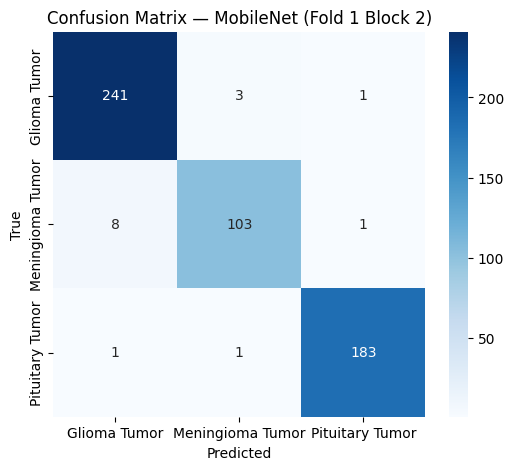

Fold: 1 block 1

Fold: 1 - Block 1
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,209,123
Non-trainable params: 928
Total mult-adds (Units.GIGABYTES): 18.17
Input si

Epoch 1/50 | loss: 0.0666 - accuracy: 0.9286 | val_loss: 0.0984 - val_accuracy: 0.8930
val_accuracy improved from 0.0000 to 0.8930, saving weights to /kaggle/working/MobileNet_block_1_fold_1.pth


Epoch 2/50 | loss: 0.0524 - accuracy: 0.9381 | val_loss: 0.0622 - val_accuracy: 0.9133
val_accuracy improved from 0.8930 to 0.9133, saving weights to /kaggle/working/MobileNet_block_1_fold_1.pth


Epoch 3/50 | loss: 0.0354 - accuracy: 0.9576 | val_loss: 0.0452 - val_accuracy: 0.9280
val_accuracy improved from 0.9133 to 0.9280, saving weights to /kaggle/working/MobileNet_block_1_fold_1.pth


Epoch 4/50 | loss: 0.0448 - accuracy: 0.9457 | val_loss: 0.0425 - val_accuracy: 0.9410
val_accuracy improved from 0.9280 to 0.9410, saving weights to /kaggle/working/MobileNet_block_1_fold_1.pth


...

Epoch 8/50 | loss: 0.0348 - accuracy: 0.9556 | val_loss: 0.0592 - val_accuracy: 0.9391
val_accuracy did not improve from 0.9649


Epoch 9/50 | loss: 0.0387 - accuracy: 0.9520 | val_loss: 0.0275 - val_accuracy: 0.9520
val_accuracy did not improve from 0.9649


Epoch 10/50 | loss: 0.0361 - accuracy: 0.9584 | val_loss: 0.0415 - val_accuracy: 0.9428
val_accuracy did not improve from 0.9649


Epoch 11/50 | loss: 0.0313 - accuracy: 0.9639 | val_loss: 0.0563 - val_accuracy: 0.9244
val_accuracy did not improve from 0.9649


Epoch 12/50 | loss: 0.0364 - accuracy: 0.9544 | val_loss: 0.0422 - val_accuracy: 0.9428
val_accuracy did not improve from 0.9649
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.032036  0.964945
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.97      0.97       245
Meningioma Tumor       0.91      0.95      0.93       112
 Pituitary Tumor       0.98      0.97      0.98       185

        accuracy                           0.96       542
       macro avg       0.96      0.96      0.96       542
    weighted avg       0.97      0.96      0.97       542



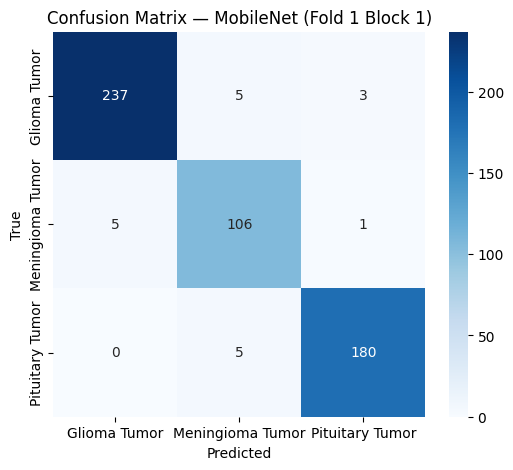

Fold: 2 block 5

Fold: 2 - Block 5
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     (3,206,976)          False
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,075
Non-trainable params: 3,206,976
Total mult-adds (Units.GIGABYTES): 18.17
Input si

Epoch 1/50 | loss: 0.4873 - accuracy: 0.4218 | val_loss: 0.4019 - val_accuracy: 0.5523
val_accuracy improved from 0.0000 to 0.5523, saving weights to /kaggle/working/MobileNet_block_5_fold_2.pth


Epoch 2/50 | loss: 0.3896 - accuracy: 0.5782 | val_loss: 0.3590 - val_accuracy: 0.6362
val_accuracy improved from 0.5523 to 0.6362, saving weights to /kaggle/working/MobileNet_block_5_fold_2.pth


Epoch 3/50 | loss: 0.3269 - accuracy: 0.6654 | val_loss: 0.3192 - val_accuracy: 0.6863
val_accuracy improved from 0.6362 to 0.6863, saving weights to /kaggle/working/MobileNet_block_5_fold_2.pth


Epoch 4/50 | loss: 0.2908 - accuracy: 0.7065 | val_loss: 0.2882 - val_accuracy: 0.7084
val_accuracy improved from 0.6863 to 0.7084, saving weights to /kaggle/working/MobileNet_block_5_fold_2.pth


...

Epoch 13/50 | loss: 0.1892 - accuracy: 0.7916 | val_loss: 0.2108 - val_accuracy: 0.7452
val_accuracy did not improve from 0.7599


Epoch 14/50 | loss: 0.1908 - accuracy: 0.7962 | val_loss: 0.2031 - val_accuracy: 0.7555
val_accuracy did not improve from 0.7599


Epoch 15/50 | loss: 0.1799 - accuracy: 0.8055 | val_loss: 0.2042 - val_accuracy: 0.7482
val_accuracy did not improve from 0.7599


Epoch 16/50 | loss: 0.1832 - accuracy: 0.8071 | val_loss: 0.2014 - val_accuracy: 0.7423
val_accuracy did not improve from 0.7599


Epoch 17/50 | loss: 0.1847 - accuracy: 0.8000 | val_loss: 0.1945 - val_accuracy: 0.7599
val_accuracy did not improve from 0.7599
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.215194  0.759941
                  precision    recall  f1-score   support

    Glioma Tumor       0.73      0.93      0.82       338
Meningioma Tumor       0.75      0.30      0.43       167
 Pituitary Tumor       0.84      0.87      0.85       174

        accuracy                           0.76       679
       macro avg       0.77      0.70      0.70       679
    weighted avg       0.76      0.76      0.73       679



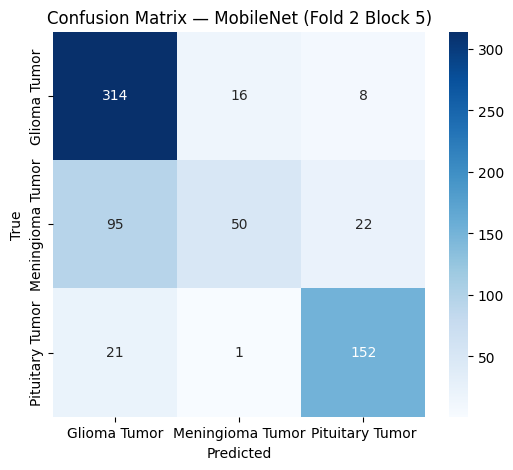

Fold: 2 block 4

Fold: 2 - Block 4
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 1,596,931
Non-trainable params: 1,613,120
Total mult-adds (Units.GIGABYTES): 18.17
In

Epoch 1/50 | loss: 0.1877 - accuracy: 0.7908 | val_loss: 0.1784 - val_accuracy: 0.7614
val_accuracy improved from 0.0000 to 0.7614, saving weights to /kaggle/working/MobileNet_block_4_fold_2.pth


Epoch 2/50 | loss: 0.1620 - accuracy: 0.8222 | val_loss: 0.1708 - val_accuracy: 0.7644
val_accuracy improved from 0.7614 to 0.7644, saving weights to /kaggle/working/MobileNet_block_4_fold_2.pth


Epoch 3/50 | loss: 0.1407 - accuracy: 0.8440 | val_loss: 0.1548 - val_accuracy: 0.7776
val_accuracy improved from 0.7644 to 0.7776, saving weights to /kaggle/working/MobileNet_block_4_fold_2.pth


Epoch 4/50 | loss: 0.1435 - accuracy: 0.8294 | val_loss: 0.1840 - val_accuracy: 0.7511
val_accuracy did not improve from 0.7776


...

Epoch 19/50 | loss: 0.0998 - accuracy: 0.8776 | val_loss: 0.1413 - val_accuracy: 0.8174
val_accuracy did not improve from 0.8203


Epoch 20/50 | loss: 0.0977 - accuracy: 0.8876 | val_loss: 0.1403 - val_accuracy: 0.8203
val_accuracy did not improve from 0.8203


Epoch 21/50 | loss: 0.0989 - accuracy: 0.8780 | val_loss: 0.1396 - val_accuracy: 0.8189
val_accuracy did not improve from 0.8203


Epoch 22/50 | loss: 0.0942 - accuracy: 0.8897 | val_loss: 0.1403 - val_accuracy: 0.8174
val_accuracy did not improve from 0.8203


Epoch 23/50 | loss: 0.0996 - accuracy: 0.8801 | val_loss: 0.1401 - val_accuracy: 0.8189
val_accuracy did not improve from 0.8203
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.136753  0.820324
                  precision    recall  f1-score   support

    Glioma Tumor       0.80      0.91      0.85       338
Meningioma Tumor       0.73      0.56      0.64       167
 Pituitary Tumor       0.95      0.89      0.92       174

        accuracy                           0.82       679
       macro avg       0.83      0.79      0.80       679
    weighted avg       0.82      0.82      0.81       679



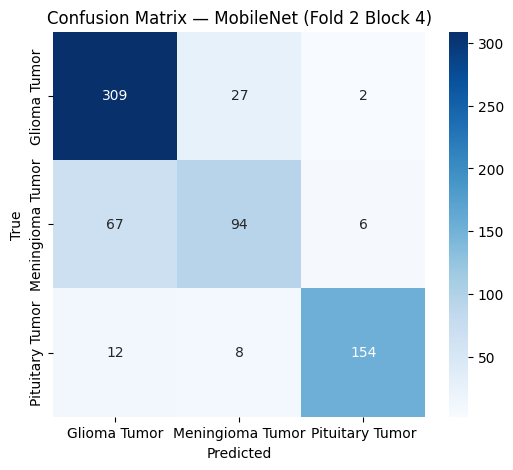

Fold: 2 block 3

Fold: 2 - Block 3
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,075,843
Non-trainable params: 134,208
Total mult-adds (Units.GIGABYTES): 18.17
Inpu

Epoch 1/50 | loss: 0.1336 - accuracy: 0.8407 | val_loss: 0.1735 - val_accuracy: 0.7717
val_accuracy improved from 0.0000 to 0.7717, saving weights to /kaggle/working/MobileNet_block_3_fold_2.pth


Epoch 2/50 | loss: 0.1194 - accuracy: 0.8637 | val_loss: 0.1157 - val_accuracy: 0.8262
val_accuracy improved from 0.7717 to 0.8262, saving weights to /kaggle/working/MobileNet_block_3_fold_2.pth


Epoch 3/50 | loss: 0.0837 - accuracy: 0.8977 | val_loss: 0.1102 - val_accuracy: 0.8660
val_accuracy improved from 0.8262 to 0.8660, saving weights to /kaggle/working/MobileNet_block_3_fold_2.pth


Epoch 4/50 | loss: 0.0899 - accuracy: 0.8939 | val_loss: 0.1133 - val_accuracy: 0.8704
val_accuracy improved from 0.8660 to 0.8704, saving weights to /kaggle/working/MobileNet_block_3_fold_2.pth


...

Epoch 16/50 | loss: 0.0217 - accuracy: 0.9736 | val_loss: 0.0777 - val_accuracy: 0.9219
val_accuracy did not improve from 0.9234


Epoch 17/50 | loss: 0.0250 - accuracy: 0.9686 | val_loss: 0.1011 - val_accuracy: 0.9219
val_accuracy did not improve from 0.9234


Epoch 18/50 | loss: 0.0185 - accuracy: 0.9786 | val_loss: 0.0950 - val_accuracy: 0.9219
val_accuracy did not improve from 0.9234


Epoch 19/50 | loss: 0.0192 - accuracy: 0.9732 | val_loss: 0.0930 - val_accuracy: 0.9234
val_accuracy did not improve from 0.9234


Epoch 20/50 | loss: 0.0186 - accuracy: 0.9782 | val_loss: 0.0972 - val_accuracy: 0.9205
val_accuracy did not improve from 0.9234
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.084845  0.923417
                  precision    recall  f1-score   support

    Glioma Tumor       0.91      0.97      0.94       338
Meningioma Tumor       0.89      0.86      0.87       167
 Pituitary Tumor       0.98      0.90      0.94       174

        accuracy                           0.92       679
       macro avg       0.93      0.91      0.92       679
    weighted avg       0.92      0.92      0.92       679



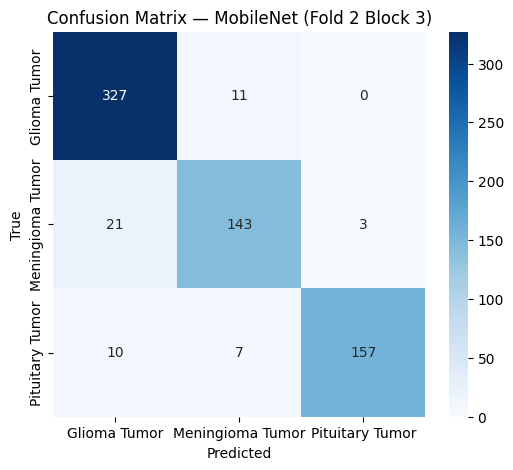

Fold: 2 block 2

Fold: 2 - Block 2
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,179,395
Non-trainable params: 30,656
Total mult-adds (Units.GIGABYTES): 18.17
Input

Epoch 1/50 | loss: 0.0560 - accuracy: 0.9333 | val_loss: 0.0807 - val_accuracy: 0.9249
val_accuracy improved from 0.0000 to 0.9249, saving weights to /kaggle/working/MobileNet_block_2_fold_2.pth


Epoch 2/50 | loss: 0.0410 - accuracy: 0.9530 | val_loss: 0.0771 - val_accuracy: 0.9102
val_accuracy did not improve from 0.9249


Epoch 3/50 | loss: 0.0494 - accuracy: 0.9455 | val_loss: 0.0742 - val_accuracy: 0.9146
val_accuracy did not improve from 0.9249


Epoch 4/50 | loss: 0.0463 - accuracy: 0.9430 | val_loss: 0.0626 - val_accuracy: 0.9308
val_accuracy improved from 0.9249 to 0.9308, saving weights to /kaggle/working/MobileNet_block_2_fold_2.pth


...

Epoch 11/50 | loss: 0.0133 - accuracy: 0.9862 | val_loss: 0.0788 - val_accuracy: 0.9367
val_accuracy did not improve from 0.9411


Epoch 12/50 | loss: 0.0158 - accuracy: 0.9828 | val_loss: 0.0831 - val_accuracy: 0.9337
val_accuracy did not improve from 0.9411


Epoch 13/50 | loss: 0.0117 - accuracy: 0.9849 | val_loss: 0.0901 - val_accuracy: 0.9337
val_accuracy did not improve from 0.9411


Epoch 14/50 | loss: 0.0117 - accuracy: 0.9857 | val_loss: 0.0862 - val_accuracy: 0.9367
val_accuracy did not improve from 0.9411


Epoch 15/50 | loss: 0.0103 - accuracy: 0.9870 | val_loss: 0.0924 - val_accuracy: 0.9352
val_accuracy did not improve from 0.9411
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.073885   0.94109
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.96      0.95       338
Meningioma Tumor       0.90      0.93      0.91       167
 Pituitary Tumor       0.98      0.93      0.95       174

        accuracy                           0.94       679
       macro avg       0.94      0.94      0.94       679
    weighted avg       0.94      0.94      0.94       679



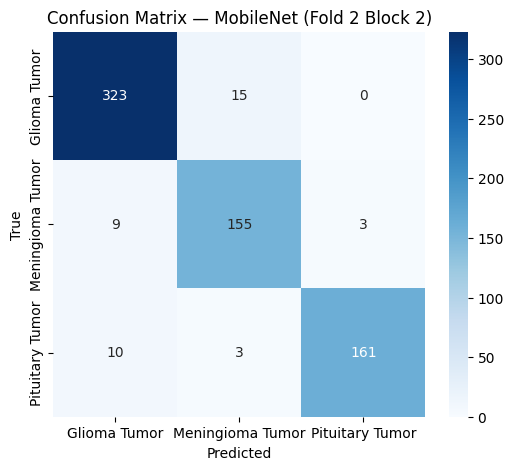

Fold: 2 block 1

Fold: 2 - Block 1
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,209,123
Non-trainable params: 928
Total mult-adds (Units.GIGABYTES): 18.17
Input si

Epoch 1/50 | loss: 0.0358 - accuracy: 0.9568 | val_loss: 0.0861 - val_accuracy: 0.9308
val_accuracy improved from 0.0000 to 0.9308, saving weights to /kaggle/working/MobileNet_block_1_fold_2.pth


Epoch 2/50 | loss: 0.0339 - accuracy: 0.9593 | val_loss: 0.1054 - val_accuracy: 0.9131
val_accuracy did not improve from 0.9308


Epoch 3/50 | loss: 0.0288 - accuracy: 0.9673 | val_loss: 0.0520 - val_accuracy: 0.9337
val_accuracy improved from 0.9308 to 0.9337, saving weights to /kaggle/working/MobileNet_block_1_fold_2.pth


Epoch 4/50 | loss: 0.0281 - accuracy: 0.9639 | val_loss: 0.0558 - val_accuracy: 0.9323
val_accuracy did not improve from 0.9337


...

Epoch 9/50 | loss: 0.0090 - accuracy: 0.9887 | val_loss: 0.0778 - val_accuracy: 0.9352
val_accuracy did not improve from 0.9411


Epoch 10/50 | loss: 0.0113 - accuracy: 0.9870 | val_loss: 0.0705 - val_accuracy: 0.9381
val_accuracy did not improve from 0.9411


Epoch 11/50 | loss: 0.0112 - accuracy: 0.9845 | val_loss: 0.0665 - val_accuracy: 0.9396
val_accuracy did not improve from 0.9411


Epoch 12/50 | loss: 0.0084 - accuracy: 0.9866 | val_loss: 0.0692 - val_accuracy: 0.9352
val_accuracy did not improve from 0.9411


Epoch 13/50 | loss: 0.0082 - accuracy: 0.9883 | val_loss: 0.0743 - val_accuracy: 0.9367
val_accuracy did not improve from 0.9411
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.052297   0.94109
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.96      0.95       338
Meningioma Tumor       0.93      0.88      0.90       167
 Pituitary Tumor       0.95      0.96      0.96       174

        accuracy                           0.94       679
       macro avg       0.94      0.93      0.94       679
    weighted avg       0.94      0.94      0.94       679



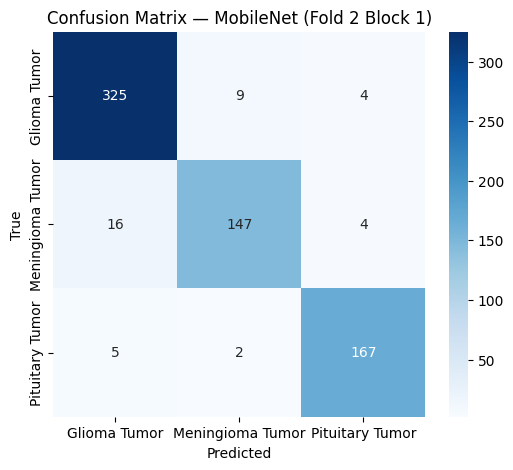

Fold: 3 block 5

Fold: 3 - Block 5
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     (3,206,976)          False
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,075
Non-trainable params: 3,206,976
Total mult-adds (Units.GIGABYTES): 18.17
Input si

Epoch 1/50 | loss: 0.5018 - accuracy: 0.4402 | val_loss: 0.4301 - val_accuracy: 0.4930
val_accuracy improved from 0.0000 to 0.4930, saving weights to /kaggle/working/MobileNet_block_5_fold_3.pth


Epoch 2/50 | loss: 0.3992 - accuracy: 0.5746 | val_loss: 0.3720 - val_accuracy: 0.5822
val_accuracy improved from 0.4930 to 0.5822, saving weights to /kaggle/working/MobileNet_block_5_fold_3.pth


Epoch 3/50 | loss: 0.3352 - accuracy: 0.6429 | val_loss: 0.3234 - val_accuracy: 0.6836
val_accuracy improved from 0.5822 to 0.6836, saving weights to /kaggle/working/MobileNet_block_5_fold_3.pth


Epoch 4/50 | loss: 0.3040 - accuracy: 0.6946 | val_loss: 0.2923 - val_accuracy: 0.7098
val_accuracy improved from 0.6836 to 0.7098, saving weights to /kaggle/working/MobileNet_block_5_fold_3.pth


...

Epoch 23/50 | loss: 0.1755 - accuracy: 0.8034 | val_loss: 0.1622 - val_accuracy: 0.8164
val_accuracy did not improve from 0.8357


Epoch 24/50 | loss: 0.1747 - accuracy: 0.8018 | val_loss: 0.1606 - val_accuracy: 0.8129
val_accuracy did not improve from 0.8357


Epoch 25/50 | loss: 0.1717 - accuracy: 0.8126 | val_loss: 0.1574 - val_accuracy: 0.8287
val_accuracy did not improve from 0.8357


Epoch 26/50 | loss: 0.1623 - accuracy: 0.8250 | val_loss: 0.1551 - val_accuracy: 0.8287
val_accuracy did not improve from 0.8357


Epoch 27/50 | loss: 0.1654 - accuracy: 0.8194 | val_loss: 0.1612 - val_accuracy: 0.8007
val_accuracy did not improve from 0.8357
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.162228  0.835664
                  precision    recall  f1-score   support

    Glioma Tumor       0.76      0.91      0.83       231
Meningioma Tumor       0.78      0.54      0.64       139
 Pituitary Tumor       0.97      0.96      0.96       202

        accuracy                           0.84       572
       macro avg       0.84      0.80      0.81       572
    weighted avg       0.84      0.84      0.83       572



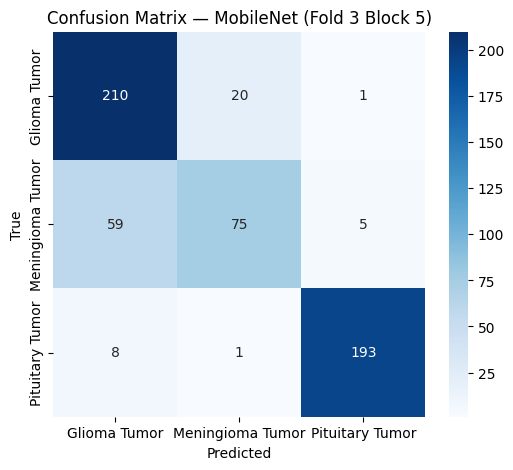

Fold: 3 block 4

Fold: 3 - Block 4
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 1,596,931
Non-trainable params: 1,613,120
Total mult-adds (Units.GIGABYTES): 18.17
In

Epoch 1/50 | loss: 0.1791 - accuracy: 0.8030 | val_loss: 0.1432 - val_accuracy: 0.8392
val_accuracy improved from 0.0000 to 0.8392, saving weights to /kaggle/working/MobileNet_block_4_fold_3.pth


Epoch 2/50 | loss: 0.1496 - accuracy: 0.8262 | val_loss: 0.1140 - val_accuracy: 0.8759
val_accuracy improved from 0.8392 to 0.8759, saving weights to /kaggle/working/MobileNet_block_4_fold_3.pth


Epoch 3/50 | loss: 0.1449 - accuracy: 0.8371 | val_loss: 0.1300 - val_accuracy: 0.8409
val_accuracy did not improve from 0.8759


Epoch 4/50 | loss: 0.1368 - accuracy: 0.8427 | val_loss: 0.1441 - val_accuracy: 0.8252
val_accuracy did not improve from 0.8759


...

Epoch 9/50 | loss: 0.1213 - accuracy: 0.8559 | val_loss: 0.1107 - val_accuracy: 0.8601
val_accuracy did not improve from 0.8829


Epoch 10/50 | loss: 0.1162 - accuracy: 0.8636 | val_loss: 0.1034 - val_accuracy: 0.8706
val_accuracy did not improve from 0.8829


Epoch 11/50 | loss: 0.1136 - accuracy: 0.8720 | val_loss: 0.1035 - val_accuracy: 0.8601
val_accuracy did not improve from 0.8829


Epoch 12/50 | loss: 0.1088 - accuracy: 0.8720 | val_loss: 0.1076 - val_accuracy: 0.8619
val_accuracy did not improve from 0.8829


Epoch 13/50 | loss: 0.1026 - accuracy: 0.8848 | val_loss: 0.1061 - val_accuracy: 0.8636
val_accuracy did not improve from 0.8829
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.104282  0.882867
                  precision    recall  f1-score   support

    Glioma Tumor       0.86      0.89      0.88       231
Meningioma Tumor       0.79      0.74      0.76       139
 Pituitary Tumor       0.97      0.97      0.97       202

        accuracy                           0.88       572
       macro avg       0.87      0.87      0.87       572
    weighted avg       0.88      0.88      0.88       572



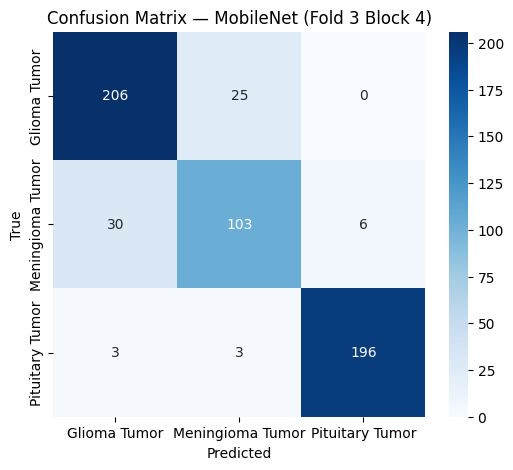

Fold: 3 block 3

Fold: 3 - Block 3
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,075,843
Non-trainable params: 134,208
Total mult-adds (Units.GIGABYTES): 18.17
Inpu

Epoch 1/50 | loss: 0.2098 - accuracy: 0.7913 | val_loss: 0.1000 - val_accuracy: 0.8741
val_accuracy improved from 0.0000 to 0.8741, saving weights to /kaggle/working/MobileNet_block_3_fold_3.pth


Epoch 2/50 | loss: 0.1125 - accuracy: 0.8591 | val_loss: 0.0779 - val_accuracy: 0.8916
val_accuracy improved from 0.8741 to 0.8916, saving weights to /kaggle/working/MobileNet_block_3_fold_3.pth


Epoch 3/50 | loss: 0.0982 - accuracy: 0.8728 | val_loss: 0.0792 - val_accuracy: 0.9021
val_accuracy improved from 0.8916 to 0.9021, saving weights to /kaggle/working/MobileNet_block_3_fold_3.pth


Epoch 4/50 | loss: 0.0980 - accuracy: 0.8816 | val_loss: 0.0836 - val_accuracy: 0.8794
val_accuracy did not improve from 0.9021


...

Epoch 10/50 | loss: 0.0560 - accuracy: 0.9350 | val_loss: 0.0608 - val_accuracy: 0.9178
val_accuracy did not improve from 0.9266


Epoch 11/50 | loss: 0.0486 - accuracy: 0.9370 | val_loss: 0.0764 - val_accuracy: 0.9056
val_accuracy did not improve from 0.9266


Epoch 12/50 | loss: 0.0505 - accuracy: 0.9418 | val_loss: 0.0688 - val_accuracy: 0.9126
val_accuracy did not improve from 0.9266


Epoch 13/50 | loss: 0.0302 - accuracy: 0.9619 | val_loss: 0.0627 - val_accuracy: 0.9231
val_accuracy did not improve from 0.9266


Epoch 14/50 | loss: 0.0253 - accuracy: 0.9671 | val_loss: 0.0702 - val_accuracy: 0.9196
val_accuracy did not improve from 0.9266
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.053475  0.926573
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.91      0.93       231
Meningioma Tumor       0.84      0.87      0.86       139
 Pituitary Tumor       0.97      0.99      0.98       202

        accuracy                           0.93       572
       macro avg       0.92      0.92      0.92       572
    weighted avg       0.93      0.93      0.93       572



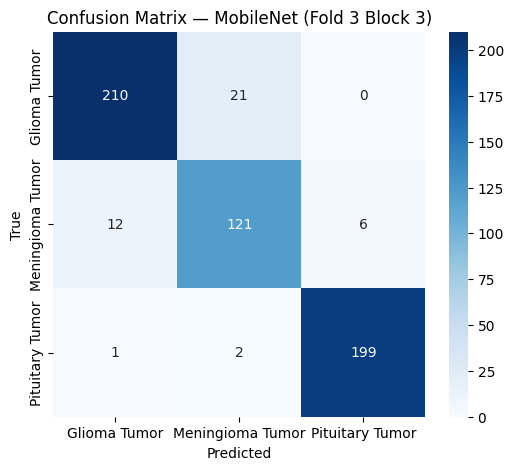

Fold: 3 block 2

Fold: 3 - Block 2
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,179,395
Non-trainable params: 30,656
Total mult-adds (Units.GIGABYTES): 18.17
Input

Epoch 1/50 | loss: 0.0734 - accuracy: 0.9141 | val_loss: 0.0770 - val_accuracy: 0.9091
val_accuracy improved from 0.0000 to 0.9091, saving weights to /kaggle/working/MobileNet_block_2_fold_3.pth


Epoch 2/50 | loss: 0.0597 - accuracy: 0.9338 | val_loss: 0.0874 - val_accuracy: 0.8899
val_accuracy did not improve from 0.9091


Epoch 3/50 | loss: 0.0583 - accuracy: 0.9294 | val_loss: 0.0763 - val_accuracy: 0.8864
val_accuracy did not improve from 0.9091


Epoch 4/50 | loss: 0.0503 - accuracy: 0.9366 | val_loss: 0.0742 - val_accuracy: 0.9056
val_accuracy did not improve from 0.9091


...

Epoch 9/50 | loss: 0.0283 - accuracy: 0.9663 | val_loss: 0.0860 - val_accuracy: 0.9038
val_accuracy did not improve from 0.9266


Epoch 10/50 | loss: 0.0254 - accuracy: 0.9707 | val_loss: 0.1087 - val_accuracy: 0.9073
val_accuracy did not improve from 0.9266


Epoch 11/50 | loss: 0.0367 - accuracy: 0.9575 | val_loss: 0.0921 - val_accuracy: 0.9038
val_accuracy did not improve from 0.9266


Epoch 12/50 | loss: 0.0199 - accuracy: 0.9763 | val_loss: 0.0613 - val_accuracy: 0.9248
val_accuracy did not improve from 0.9266


Epoch 13/50 | loss: 0.0177 - accuracy: 0.9755 | val_loss: 0.0643 - val_accuracy: 0.9266
val_accuracy did not improve from 0.9266
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.062019  0.926573
                  precision    recall  f1-score   support

    Glioma Tumor       0.92      0.95      0.94       231
Meningioma Tumor       0.91      0.78      0.84       139
 Pituitary Tumor       0.94      1.00      0.97       202

        accuracy                           0.93       572
       macro avg       0.92      0.91      0.91       572
    weighted avg       0.93      0.93      0.92       572



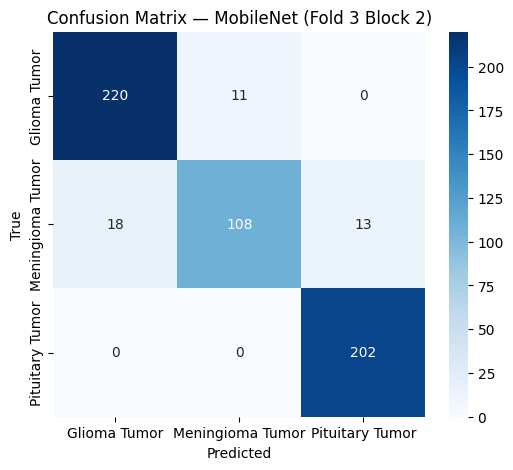

Fold: 3 block 1

Fold: 3 - Block 1
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,209,123
Non-trainable params: 928
Total mult-adds (Units.GIGABYTES): 18.17
Input si

Epoch 1/50 | loss: 0.0588 - accuracy: 0.9338 | val_loss: 0.0698 - val_accuracy: 0.9108
val_accuracy improved from 0.0000 to 0.9108, saving weights to /kaggle/working/MobileNet_block_1_fold_3.pth


Epoch 2/50 | loss: 0.0363 - accuracy: 0.9583 | val_loss: 0.0808 - val_accuracy: 0.9126
val_accuracy improved from 0.9108 to 0.9126, saving weights to /kaggle/working/MobileNet_block_1_fold_3.pth


Epoch 3/50 | loss: 0.0415 - accuracy: 0.9518 | val_loss: 0.0536 - val_accuracy: 0.9336
val_accuracy improved from 0.9126 to 0.9336, saving weights to /kaggle/working/MobileNet_block_1_fold_3.pth


Epoch 4/50 | loss: 0.0365 - accuracy: 0.9611 | val_loss: 0.0650 - val_accuracy: 0.9336
val_accuracy did not improve from 0.9336


Epoch 5/50 | loss: 0.0281 - accuracy: 0.9647 | val_loss: 0.0706 - val_accuracy: 0.9231
val_accuracy did not improve from 0.9336


Epoch 6/50 | loss: 0.0383 - accuracy: 0.9539 | val_loss: 0.0587 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9336


Epoch 7/50 | loss: 0.0344 - accuracy: 0.9603 | val_loss: 0.0954 - val_accuracy: 0.9091
val_accuracy did not improve from 0.9336


Epoch 8/50 | loss: 0.0237 - accuracy: 0.9695 | val_loss: 0.0660 - val_accuracy: 0.9301
val_accuracy did not improve from 0.9336


Epoch 9/50 | loss: 0.0175 - accuracy: 0.9747 | val_loss: 0.0652 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9336
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.053599  0.933566
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.93      0.94       231
Meningioma Tumor       0.86      0.86      0.86       139
 Pituitary Tumor       0.96      0.99      0.97       202

        accuracy                           0.93       572
       macro avg       0.93      0.93      0.93       572
    weighted avg       0.93      0.93      0.93       572



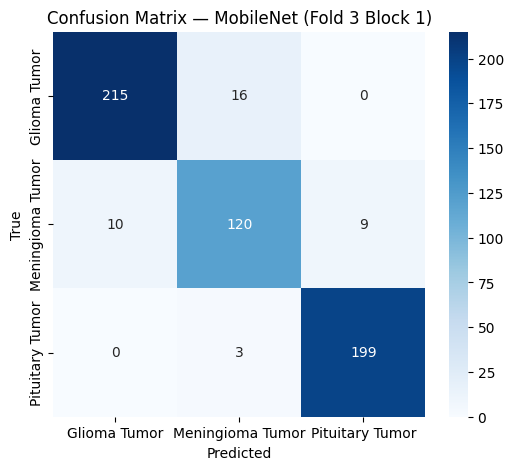

Fold: 4 block 5

Fold: 4 - Block 5
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     (3,206,976)          False
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,075
Non-trainable params: 3,206,976
Total mult-adds (Units.GIGABYTES): 18.17
Input si

Epoch 1/50 | loss: 0.4743 - accuracy: 0.4610 | val_loss: 0.3776 - val_accuracy: 0.6561
val_accuracy improved from 0.0000 to 0.6561, saving weights to /kaggle/working/MobileNet_block_5_fold_4.pth


Epoch 2/50 | loss: 0.3748 - accuracy: 0.6006 | val_loss: 0.3109 - val_accuracy: 0.7357
val_accuracy improved from 0.6561 to 0.7357, saving weights to /kaggle/working/MobileNet_block_5_fold_4.pth


Epoch 3/50 | loss: 0.3188 - accuracy: 0.6847 | val_loss: 0.2827 - val_accuracy: 0.7707
val_accuracy improved from 0.7357 to 0.7707, saving weights to /kaggle/working/MobileNet_block_5_fold_4.pth


Epoch 4/50 | loss: 0.2932 - accuracy: 0.7044 | val_loss: 0.2594 - val_accuracy: 0.7691
val_accuracy did not improve from 0.7707


...

Epoch 36/50 | loss: 0.1610 - accuracy: 0.8259 | val_loss: 0.1412 - val_accuracy: 0.8392
val_accuracy did not improve from 0.8503


Epoch 37/50 | loss: 0.1585 - accuracy: 0.8251 | val_loss: 0.1384 - val_accuracy: 0.8471
val_accuracy did not improve from 0.8503


Epoch 38/50 | loss: 0.1569 - accuracy: 0.8309 | val_loss: 0.1385 - val_accuracy: 0.8471
val_accuracy did not improve from 0.8503


Epoch 39/50 | loss: 0.1494 - accuracy: 0.8387 | val_loss: 0.1383 - val_accuracy: 0.8503
val_accuracy did not improve from 0.8503


Epoch 40/50 | loss: 0.1565 - accuracy: 0.8210 | val_loss: 0.1383 - val_accuracy: 0.8487
val_accuracy did not improve from 0.8503
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.139786  0.850318
                  precision    recall  f1-score   support

    Glioma Tumor       0.87      0.90      0.88       325
Meningioma Tumor       0.68      0.60      0.64       124
 Pituitary Tumor       0.92      0.93      0.92       179

        accuracy                           0.85       628
       macro avg       0.82      0.81      0.82       628
    weighted avg       0.85      0.85      0.85       628



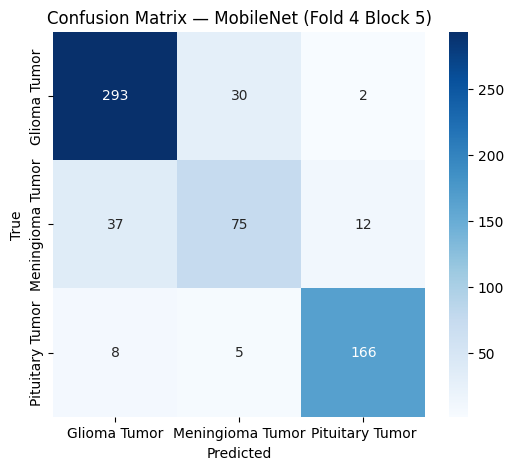

Fold: 4 block 4

Fold: 4 - Block 4
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 1,596,931
Non-trainable params: 1,613,120
Total mult-adds (Units.GIGABYTES): 18.17
In

Epoch 1/50 | loss: 0.1583 - accuracy: 0.8198 | val_loss: 0.1381 - val_accuracy: 0.8408
val_accuracy improved from 0.0000 to 0.8408, saving weights to /kaggle/working/MobileNet_block_4_fold_4.pth


Epoch 2/50 | loss: 0.1387 - accuracy: 0.8387 | val_loss: 0.1378 - val_accuracy: 0.8487
val_accuracy improved from 0.8408 to 0.8487, saving weights to /kaggle/working/MobileNet_block_4_fold_4.pth


Epoch 3/50 | loss: 0.1462 - accuracy: 0.8337 | val_loss: 0.1213 - val_accuracy: 0.8487
val_accuracy did not improve from 0.8487


Epoch 4/50 | loss: 0.1437 - accuracy: 0.8259 | val_loss: 0.1120 - val_accuracy: 0.8662
val_accuracy improved from 0.8487 to 0.8662, saving weights to /kaggle/working/MobileNet_block_4_fold_4.pth


...

Epoch 7/50 | loss: 0.1259 - accuracy: 0.8571 | val_loss: 0.1066 - val_accuracy: 0.8599
val_accuracy did not improve from 0.8758


Epoch 8/50 | loss: 0.1181 - accuracy: 0.8514 | val_loss: 0.1160 - val_accuracy: 0.8455
val_accuracy did not improve from 0.8758


Epoch 9/50 | loss: 0.1239 - accuracy: 0.8588 | val_loss: 0.1213 - val_accuracy: 0.8408
val_accuracy did not improve from 0.8758


Epoch 10/50 | loss: 0.1080 - accuracy: 0.8805 | val_loss: 0.0985 - val_accuracy: 0.8758
val_accuracy did not improve from 0.8758


Epoch 11/50 | loss: 0.1008 - accuracy: 0.8797 | val_loss: 0.1023 - val_accuracy: 0.8662
val_accuracy did not improve from 0.8758
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.106605  0.875796
                  precision    recall  f1-score   support

    Glioma Tumor       0.88      0.93      0.90       325
Meningioma Tumor       0.74      0.60      0.67       124
 Pituitary Tumor       0.94      0.97      0.95       179

        accuracy                           0.88       628
       macro avg       0.85      0.83      0.84       628
    weighted avg       0.87      0.88      0.87       628



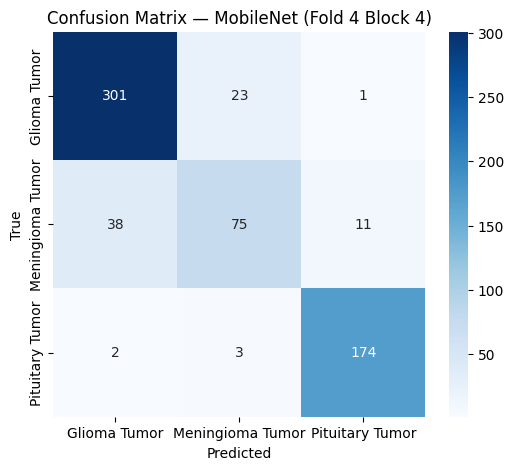

Fold: 4 block 3

Fold: 4 - Block 3
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,075,843
Non-trainable params: 134,208
Total mult-adds (Units.GIGABYTES): 18.17
Inpu

Epoch 1/50 | loss: 0.1900 - accuracy: 0.7911 | val_loss: 0.1397 - val_accuracy: 0.8185
val_accuracy improved from 0.0000 to 0.8185, saving weights to /kaggle/working/MobileNet_block_3_fold_4.pth


Epoch 2/50 | loss: 0.1465 - accuracy: 0.8333 | val_loss: 0.0860 - val_accuracy: 0.8838
val_accuracy improved from 0.8185 to 0.8838, saving weights to /kaggle/working/MobileNet_block_3_fold_4.pth


Epoch 3/50 | loss: 0.1306 - accuracy: 0.8432 | val_loss: 0.0769 - val_accuracy: 0.8869
val_accuracy improved from 0.8838 to 0.8869, saving weights to /kaggle/working/MobileNet_block_3_fold_4.pth


Epoch 4/50 | loss: 0.0904 - accuracy: 0.8892 | val_loss: 0.0697 - val_accuracy: 0.9252
val_accuracy improved from 0.8869 to 0.9252, saving weights to /kaggle/working/MobileNet_block_3_fold_4.pth


...

Epoch 18/50 | loss: 0.0308 - accuracy: 0.9548 | val_loss: 0.0468 - val_accuracy: 0.9586
val_accuracy did not improve from 0.9634


Epoch 19/50 | loss: 0.0265 - accuracy: 0.9659 | val_loss: 0.0450 - val_accuracy: 0.9522
val_accuracy did not improve from 0.9634


Epoch 20/50 | loss: 0.0253 - accuracy: 0.9647 | val_loss: 0.0391 - val_accuracy: 0.9570
val_accuracy did not improve from 0.9634


Epoch 21/50 | loss: 0.0255 - accuracy: 0.9655 | val_loss: 0.0411 - val_accuracy: 0.9570
val_accuracy did not improve from 0.9634


Epoch 22/50 | loss: 0.0245 - accuracy: 0.9643 | val_loss: 0.0408 - val_accuracy: 0.9586
val_accuracy did not improve from 0.9634
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.040157  0.963376
                  precision    recall  f1-score   support

    Glioma Tumor       0.99      0.97      0.98       325
Meningioma Tumor       0.89      0.95      0.92       124
 Pituitary Tumor       0.98      0.96      0.97       179

        accuracy                           0.96       628
       macro avg       0.95      0.96      0.96       628
    weighted avg       0.96      0.96      0.96       628



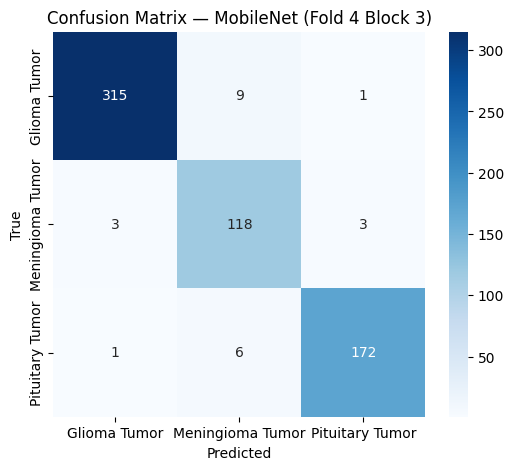

Fold: 4 block 2

Fold: 4 - Block 2
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,179,395
Non-trainable params: 30,656
Total mult-adds (Units.GIGABYTES): 18.17
Input

Epoch 1/50 | loss: 0.0622 - accuracy: 0.9273 | val_loss: 0.0465 - val_accuracy: 0.9411
val_accuracy improved from 0.0000 to 0.9411, saving weights to /kaggle/working/MobileNet_block_2_fold_4.pth


Epoch 2/50 | loss: 0.0479 - accuracy: 0.9405 | val_loss: 0.0892 - val_accuracy: 0.8949
val_accuracy did not improve from 0.9411


Epoch 3/50 | loss: 0.0485 - accuracy: 0.9397 | val_loss: 0.0508 - val_accuracy: 0.9522
val_accuracy improved from 0.9411 to 0.9522, saving weights to /kaggle/working/MobileNet_block_2_fold_4.pth


Epoch 4/50 | loss: 0.0377 - accuracy: 0.9511 | val_loss: 0.0599 - val_accuracy: 0.9315
val_accuracy did not improve from 0.9522


...

Epoch 8/50 | loss: 0.0205 - accuracy: 0.9741 | val_loss: 0.0441 - val_accuracy: 0.9506
val_accuracy did not improve from 0.9697


Epoch 9/50 | loss: 0.0229 - accuracy: 0.9676 | val_loss: 0.0417 - val_accuracy: 0.9634
val_accuracy did not improve from 0.9697


Epoch 10/50 | loss: 0.0207 - accuracy: 0.9733 | val_loss: 0.0408 - val_accuracy: 0.9618
val_accuracy did not improve from 0.9697


Epoch 11/50 | loss: 0.0166 - accuracy: 0.9782 | val_loss: 0.0414 - val_accuracy: 0.9602
val_accuracy did not improve from 0.9697


Epoch 12/50 | loss: 0.0126 - accuracy: 0.9865 | val_loss: 0.0409 - val_accuracy: 0.9618
val_accuracy did not improve from 0.9697
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.040443  0.969745
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.98      0.98       325
Meningioma Tumor       0.90      0.98      0.94       124
 Pituitary Tumor       0.99      0.96      0.97       179

        accuracy                           0.97       628
       macro avg       0.96      0.97      0.96       628
    weighted avg       0.97      0.97      0.97       628



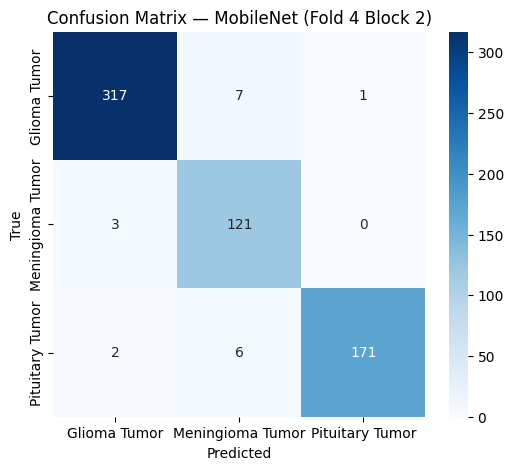

Fold: 4 block 1

Fold: 4 - Block 1
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,209,123
Non-trainable params: 928
Total mult-adds (Units.GIGABYTES): 18.17
Input si

Epoch 1/50 | loss: 0.0613 - accuracy: 0.9335 | val_loss: 0.0674 - val_accuracy: 0.9395
val_accuracy improved from 0.0000 to 0.9395, saving weights to /kaggle/working/MobileNet_block_1_fold_4.pth


Epoch 2/50 | loss: 0.0535 - accuracy: 0.9294 | val_loss: 0.0549 - val_accuracy: 0.9379
val_accuracy did not improve from 0.9395


Epoch 3/50 | loss: 0.0399 - accuracy: 0.9503 | val_loss: 0.0523 - val_accuracy: 0.9506
val_accuracy improved from 0.9395 to 0.9506, saving weights to /kaggle/working/MobileNet_block_1_fold_4.pth


Epoch 4/50 | loss: 0.0348 - accuracy: 0.9606 | val_loss: 0.0774 - val_accuracy: 0.9045
val_accuracy did not improve from 0.9506


...

Epoch 10/50 | loss: 0.0284 - accuracy: 0.9688 | val_loss: 0.0473 - val_accuracy: 0.9602
val_accuracy did not improve from 0.9634


Epoch 11/50 | loss: 0.0312 - accuracy: 0.9635 | val_loss: 0.0701 - val_accuracy: 0.9331
val_accuracy did not improve from 0.9634


Epoch 12/50 | loss: 0.0422 - accuracy: 0.9483 | val_loss: 0.0545 - val_accuracy: 0.9538
val_accuracy did not improve from 0.9634


Epoch 13/50 | loss: 0.0205 - accuracy: 0.9787 | val_loss: 0.0394 - val_accuracy: 0.9586
val_accuracy did not improve from 0.9634


Epoch 14/50 | loss: 0.0141 - accuracy: 0.9811 | val_loss: 0.0399 - val_accuracy: 0.9602
val_accuracy did not improve from 0.9634
early stopping, restoring model weights from the end of the best epoch
       Model     Loss  Accuracy
0  MobileNet  0.04301  0.963376
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.98      0.98       325
Meningioma Tumor       0.90      0.94      0.92       124
 Pituitary Tumor       0.98      0.95      0.96       179

        accuracy                           0.96       628
       macro avg       0.95      0.96      0.95       628
    weighted avg       0.96      0.96      0.96       628



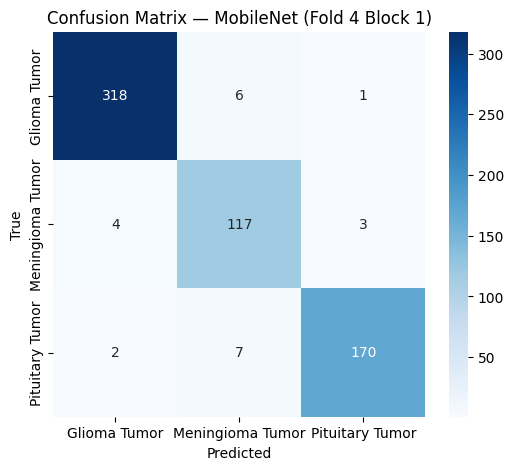

Fold: 5 block 5

Fold: 5 - Block 5
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     (3,206,976)          False
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,075
Non-trainable params: 3,206,976
Total mult-adds (Units.GIGABYTES): 18.17
Input si

Epoch 1/50 | loss: 0.4557 - accuracy: 0.4787 | val_loss: 0.4143 - val_accuracy: 0.5879
val_accuracy improved from 0.0000 to 0.5879, saving weights to /kaggle/working/MobileNet_block_5_fold_5.pth


Epoch 2/50 | loss: 0.3594 - accuracy: 0.6196 | val_loss: 0.3636 - val_accuracy: 0.6672
val_accuracy improved from 0.5879 to 0.6672, saving weights to /kaggle/working/MobileNet_block_5_fold_5.pth


Epoch 3/50 | loss: 0.3154 - accuracy: 0.6857 | val_loss: 0.3478 - val_accuracy: 0.6594
val_accuracy did not improve from 0.6672


Epoch 4/50 | loss: 0.2799 - accuracy: 0.7216 | val_loss: 0.3198 - val_accuracy: 0.6765
val_accuracy improved from 0.6672 to 0.6765, saving weights to /kaggle/working/MobileNet_block_5_fold_5.pth


...

Epoch 21/50 | loss: 0.1578 - accuracy: 0.8236 | val_loss: 0.2124 - val_accuracy: 0.7589
val_accuracy did not improve from 0.7652


Epoch 22/50 | loss: 0.1551 - accuracy: 0.8315 | val_loss: 0.2206 - val_accuracy: 0.7589
val_accuracy did not improve from 0.7652


Epoch 23/50 | loss: 0.1593 - accuracy: 0.8104 | val_loss: 0.2052 - val_accuracy: 0.7652
val_accuracy did not improve from 0.7652


Epoch 24/50 | loss: 0.1521 - accuracy: 0.8298 | val_loss: 0.2137 - val_accuracy: 0.7527
val_accuracy did not improve from 0.7652


Epoch 25/50 | loss: 0.1541 - accuracy: 0.8191 | val_loss: 0.2034 - val_accuracy: 0.7652
val_accuracy did not improve from 0.7652
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.224754  0.765163
                  precision    recall  f1-score   support

    Glioma Tumor       0.73      0.94      0.83       287
Meningioma Tumor       0.80      0.30      0.43       166
 Pituitary Tumor       0.81      0.91      0.85       190

        accuracy                           0.77       643
       macro avg       0.78      0.71      0.70       643
    weighted avg       0.77      0.77      0.73       643



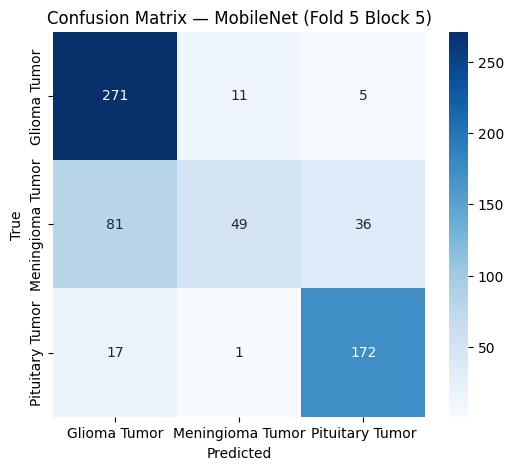

Fold: 5 block 4

Fold: 5 - Block 4
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 1,596,931
Non-trainable params: 1,613,120
Total mult-adds (Units.GIGABYTES): 18.17
In

Epoch 1/50 | loss: 0.1662 - accuracy: 0.8034 | val_loss: 0.2223 - val_accuracy: 0.7729
val_accuracy improved from 0.0000 to 0.7729, saving weights to /kaggle/working/MobileNet_block_4_fold_5.pth


Epoch 2/50 | loss: 0.1423 - accuracy: 0.8265 | val_loss: 0.2299 - val_accuracy: 0.7932
val_accuracy improved from 0.7729 to 0.7932, saving weights to /kaggle/working/MobileNet_block_4_fold_5.pth


Epoch 3/50 | loss: 0.1313 - accuracy: 0.8546 | val_loss: 0.1985 - val_accuracy: 0.7900
val_accuracy did not improve from 0.7932


Epoch 4/50 | loss: 0.1292 - accuracy: 0.8459 | val_loss: 0.1900 - val_accuracy: 0.7823
val_accuracy did not improve from 0.7932


...

Epoch 9/50 | loss: 0.1074 - accuracy: 0.8670 | val_loss: 0.1838 - val_accuracy: 0.8243
val_accuracy did not improve from 0.8258


Epoch 10/50 | loss: 0.0998 - accuracy: 0.8707 | val_loss: 0.1736 - val_accuracy: 0.8180
val_accuracy did not improve from 0.8258


Epoch 11/50 | loss: 0.1030 - accuracy: 0.8781 | val_loss: 0.1646 - val_accuracy: 0.8165
val_accuracy did not improve from 0.8258


Epoch 12/50 | loss: 0.0993 - accuracy: 0.8736 | val_loss: 0.1769 - val_accuracy: 0.7978
val_accuracy did not improve from 0.8258


Epoch 13/50 | loss: 0.0968 - accuracy: 0.8815 | val_loss: 0.1741 - val_accuracy: 0.7916
val_accuracy did not improve from 0.8258
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.166904  0.825816
                  precision    recall  f1-score   support

    Glioma Tumor       0.89      0.83      0.86       287
Meningioma Tumor       0.68      0.71      0.69       166
 Pituitary Tumor       0.86      0.93      0.89       190

        accuracy                           0.83       643
       macro avg       0.81      0.82      0.82       643
    weighted avg       0.83      0.83      0.83       643



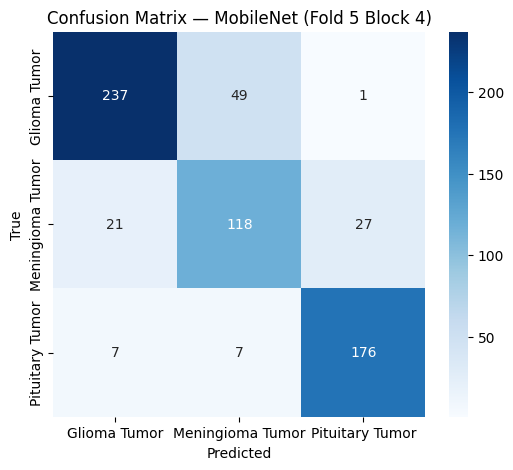

Fold: 5 block 3

Fold: 5 - Block 3
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,075,843
Non-trainable params: 134,208
Total mult-adds (Units.GIGABYTES): 18.17
Inpu

Epoch 1/50 | loss: 0.1615 - accuracy: 0.8327 | val_loss: 0.2293 - val_accuracy: 0.7776
val_accuracy improved from 0.0000 to 0.7776, saving weights to /kaggle/working/MobileNet_block_3_fold_5.pth


Epoch 2/50 | loss: 0.0998 - accuracy: 0.8744 | val_loss: 0.1955 - val_accuracy: 0.8212
val_accuracy improved from 0.7776 to 0.8212, saving weights to /kaggle/working/MobileNet_block_3_fold_5.pth


Epoch 3/50 | loss: 0.0707 - accuracy: 0.9186 | val_loss: 0.1483 - val_accuracy: 0.8180
val_accuracy did not improve from 0.8212


Epoch 4/50 | loss: 0.0725 - accuracy: 0.9120 | val_loss: 0.1651 - val_accuracy: 0.8585
val_accuracy improved from 0.8212 to 0.8585, saving weights to /kaggle/working/MobileNet_block_3_fold_5.pth


...

Epoch 13/50 | loss: 0.0267 - accuracy: 0.9686 | val_loss: 0.1644 - val_accuracy: 0.8865
val_accuracy did not improve from 0.8880


Epoch 14/50 | loss: 0.0266 - accuracy: 0.9665 | val_loss: 0.1471 - val_accuracy: 0.8787
val_accuracy did not improve from 0.8880


Epoch 15/50 | loss: 0.0252 - accuracy: 0.9686 | val_loss: 0.1550 - val_accuracy: 0.8865
val_accuracy did not improve from 0.8880


Epoch 16/50 | loss: 0.0243 - accuracy: 0.9686 | val_loss: 0.1587 - val_accuracy: 0.8880
val_accuracy did not improve from 0.8880


Epoch 17/50 | loss: 0.0225 - accuracy: 0.9723 | val_loss: 0.1608 - val_accuracy: 0.8865
val_accuracy did not improve from 0.8880
early stopping, restoring model weights from the end of the best epoch
       Model     Loss  Accuracy
0  MobileNet  0.15909  0.888025
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.89      0.93       287
Meningioma Tumor       0.77      0.81      0.79       166
 Pituitary Tumor       0.88      0.96      0.92       190

        accuracy                           0.89       643
       macro avg       0.87      0.89      0.88       643
    weighted avg       0.89      0.89      0.89       643



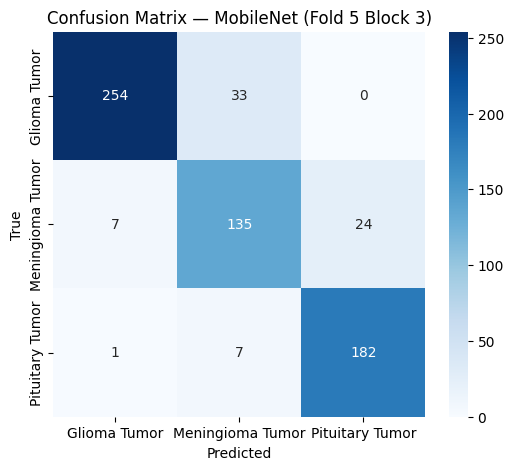

Fold: 5 block 2

Fold: 5 - Block 2
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,179,395
Non-trainable params: 30,656
Total mult-adds (Units.GIGABYTES): 18.17
Input

Epoch 1/50 | loss: 0.0463 - accuracy: 0.9434 | val_loss: 0.1436 - val_accuracy: 0.8476
val_accuracy improved from 0.0000 to 0.8476, saving weights to /kaggle/working/MobileNet_block_2_fold_5.pth


Epoch 2/50 | loss: 0.0489 - accuracy: 0.9459 | val_loss: 0.1895 - val_accuracy: 0.8616
val_accuracy improved from 0.8476 to 0.8616, saving weights to /kaggle/working/MobileNet_block_2_fold_5.pth


Epoch 3/50 | loss: 0.0435 - accuracy: 0.9480 | val_loss: 0.1870 - val_accuracy: 0.8725
val_accuracy improved from 0.8616 to 0.8725, saving weights to /kaggle/working/MobileNet_block_2_fold_5.pth


Epoch 4/50 | loss: 0.0440 - accuracy: 0.9430 | val_loss: 0.1433 - val_accuracy: 0.8600
val_accuracy did not improve from 0.8725


...

Epoch 15/50 | loss: 0.0093 - accuracy: 0.9888 | val_loss: 0.1823 - val_accuracy: 0.8927
val_accuracy did not improve from 0.8942


Epoch 16/50 | loss: 0.0105 - accuracy: 0.9851 | val_loss: 0.1775 - val_accuracy: 0.8880
val_accuracy did not improve from 0.8942


Epoch 17/50 | loss: 0.0108 - accuracy: 0.9843 | val_loss: 0.1819 - val_accuracy: 0.8880
val_accuracy did not improve from 0.8942


Epoch 18/50 | loss: 0.0104 - accuracy: 0.9888 | val_loss: 0.1782 - val_accuracy: 0.8896
val_accuracy did not improve from 0.8942


Epoch 19/50 | loss: 0.0132 - accuracy: 0.9835 | val_loss: 0.1775 - val_accuracy: 0.8911
val_accuracy did not improve from 0.8942
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.194229  0.894246
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.88      0.93       287
Meningioma Tumor       0.80      0.81      0.81       166
 Pituitary Tumor       0.87      0.98      0.92       190

        accuracy                           0.89       643
       macro avg       0.88      0.89      0.89       643
    weighted avg       0.90      0.89      0.89       643



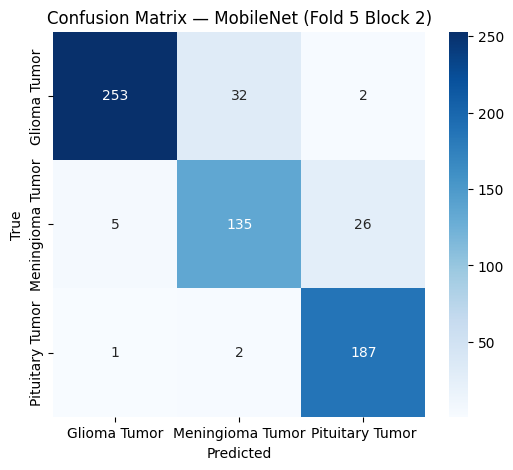

Fold: 5 block 1

Fold: 5 - Block 1
Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
MobileNet (MobileNet)                              [32, 3, 224, 224]    [32, 3]              --                   Partial
├─EfficientNet (backbone)                          [32, 3, 224, 224]    [32, 1024, 7, 7]     3,206,976            Partial
├─AdaptiveAvgPool2d (global_avg_pool)              [32, 1024, 7, 7]     [32, 1024, 1, 1]     --                   --
├─Flatten (flatten)                                [32, 1024, 1, 1]     [32, 1024]           --                   --
├─Dropout (dropout)                                [32, 1024]           [32, 1024]           --                   --
├─Linear (classifier)                              [32, 1024]           [32, 3]              3,075                True
Total params: 3,210,051
Trainable params: 3,209,123
Non-trainable params: 928
Total mult-adds (Units.GIGABYTES): 18.17
Input si

Epoch 1/50 | loss: 0.0491 - accuracy: 0.9442 | val_loss: 0.1442 - val_accuracy: 0.8911
val_accuracy improved from 0.0000 to 0.8911, saving weights to /kaggle/working/MobileNet_block_1_fold_5.pth


Epoch 2/50 | loss: 0.0395 - accuracy: 0.9587 | val_loss: 0.2956 - val_accuracy: 0.8538
val_accuracy did not improve from 0.8911


Epoch 3/50 | loss: 0.0364 - accuracy: 0.9587 | val_loss: 0.1328 - val_accuracy: 0.8942
val_accuracy improved from 0.8911 to 0.8942, saving weights to /kaggle/working/MobileNet_block_1_fold_5.pth


Epoch 4/50 | loss: 0.0296 - accuracy: 0.9637 | val_loss: 0.1671 - val_accuracy: 0.9020
val_accuracy improved from 0.8942 to 0.9020, saving weights to /kaggle/working/MobileNet_block_1_fold_5.pth


...

Epoch 12/50 | loss: 0.0092 - accuracy: 0.9913 | val_loss: 0.1955 - val_accuracy: 0.9020
val_accuracy did not improve from 0.9067


Epoch 13/50 | loss: 0.0090 - accuracy: 0.9868 | val_loss: 0.2076 - val_accuracy: 0.9005
val_accuracy did not improve from 0.9067


Epoch 14/50 | loss: 0.0071 - accuracy: 0.9926 | val_loss: 0.1874 - val_accuracy: 0.9036
val_accuracy did not improve from 0.9067


Epoch 15/50 | loss: 0.0067 - accuracy: 0.9930 | val_loss: 0.2001 - val_accuracy: 0.9036
val_accuracy did not improve from 0.9067


Epoch 16/50 | loss: 0.0079 - accuracy: 0.9872 | val_loss: 0.2014 - val_accuracy: 0.9020
val_accuracy did not improve from 0.9067
early stopping, restoring model weights from the end of the best epoch
       Model      Loss  Accuracy
0  MobileNet  0.203391  0.906687
                  precision    recall  f1-score   support

    Glioma Tumor       0.99      0.90      0.94       287
Meningioma Tumor       0.83      0.83      0.83       166
 Pituitary Tumor       0.87      0.99      0.92       190

        accuracy                           0.91       643
       macro avg       0.89      0.90      0.90       643
    weighted avg       0.91      0.91      0.91       643



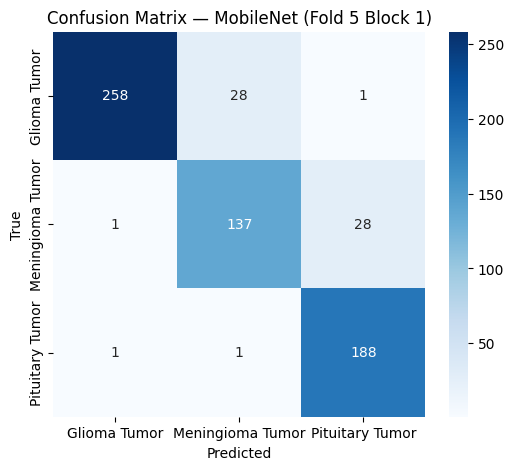

In [18]:
acc_b1, acc_b2, acc_b3, acc_b4, acc_b5 = [], [], [], [], []

for fold_k in range(1, 6):
    print(f'Fold: {fold_k} block 5')
    train_loader, val_loader = get_data_for_fold(k=fold_k)

    acc_b5.append(test_classifier(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k))

    torch.cuda.empty_cache()
    gc.collect()

    for block in range(4, 0, -1):
        print(f'Fold: {fold_k} block {block}')
        acc_list = [None, acc_b1, acc_b2, acc_b3, acc_b4, acc_b5]
        acc_list[block].append(test_block(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k, block=block))

        torch.cuda.empty_cache()
        gc.collect()

    del train_loader, val_loader
    torch.cuda.empty_cache()
    gc.collect()

In [19]:
ACC_BLOCK = [acc_b5, acc_b4, acc_b3, acc_b2, acc_b1]

for _, acc in enumerate(ACC_BLOCK):
    print(f'Accuracy unfreeze block {5 - _} - block 5: {np.mean(acc) * 100:.2f}%')

Accuracy unfreeze block 5 - block 5: 80.83%
Accuracy unfreeze block 4 - block 5: 86.32%
Accuracy unfreeze block 3 - block 5: 93.22%
Accuracy unfreeze block 2 - block 5: 94.08%
Accuracy unfreeze block 1 - block 5: 94.19%
